# AutoSort Evaluation Pipeline

Main steps:
1. Load data (same as training)
2. Prepare evaluation data for each time segment
3. Load models and evaluate for each clique and time segment


In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
import gc
import torch
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface.core import concatenate_recordings
from probeinterface import write_probeinterface, read_probeinterface
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils_clique import (
    prepare_evaluation_data_no_whiten,
    evaluate_spike_cnn,
    CliqueInfo,
    load_clique_info
)


In [2]:
# Channel list (same as training)
channel_list_A = ['A-000', 'A-001', 'A-002',
       'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
       'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-016',
       'A-017', 'A-018', 'A-019', 'A-020', 'A-021', 'A-022', 'A-023',
       'A-024', 'A-025', 'A-026', 'A-027', 'A-028', 'A-029', 'A-030',
       'A-031', 'A-032', 'A-033', 'A-034', 'A-035', 'A-036', 'A-037',
       'A-038', 'A-039', 'A-040', 'A-041', 'A-042', 'A-043', 'A-044',
       'A-045', 'A-046', 'A-047', 'A-048', 'A-049', 'A-050', 'A-051',
       'A-052', 'A-053', 'A-054', 'A-055', 'A-056', 'A-057', 'A-058',
       'A-059', 'A-060', 'A-061', 'A-062', 'A-063', 'A-064', 'A-065',
       'A-066', 'A-067', 'A-068', 'A-069', 'A-070', 'A-071', 'A-072',
       'A-073', 'A-074', 'A-075', 'A-076', 'A-077', 'A-078', 'A-079',
       'A-080', 'A-081', 'A-082', 'A-083', 'A-084', 'A-085', 'A-086',
       'A-087', 'A-088', 'A-089', 'A-090', 'A-091', 'A-092', 'A-093',
       'A-094', 'A-095', 'A-096', 'A-097', 'A-098', 'A-099', 'A-100',
       'A-101', 'A-102', 'A-103', 'A-104', 'A-105', 'A-106', 'A-107',
       'A-108', 'A-109', 'A-110', 'A-111', 'A-112', 'A-113', 'A-114',
       'A-115', 'A-116', 'A-117', 'A-118', 'A-119', 'A-120', 'A-121',
       'A-122', 'A-123', 'A-124', 'A-125', 'A-126', 'A-127']

channel_list = ['B-000', 'B-001', 'B-002',
       'B-003', 'B-004', 'B-005', 'B-006', 'B-007', 'B-008', 'B-009',
       'B-010', 'B-011', 'B-012', 'B-013', 'B-014', 'B-015', 'B-016',
       'B-017', 'B-018', 'B-019', 'B-020', 'B-021', 'B-022', 'B-023',
       'B-024', 'B-025', 'B-026', 'B-027', 'B-028', 'B-029', 'B-030',
       'B-031', 'B-032', 'B-033', 'B-034', 'B-035', 'B-036', 'B-037',
       'B-038', 'B-039', 'B-040', 'B-041', 'B-042', 'B-043', 'B-044',
       'B-045', 'B-046', 'B-047', 'B-048', 'B-049', 'B-050', 'B-051',
       'B-052', 'B-053', 'B-054', 'B-055', 'B-056', 'B-057', 'B-058',
       'B-059', 'B-060', 'B-061', 'B-062', 'B-063', 'B-064', 'B-065',
       'B-066', 'B-067', 'B-068', 'B-069', 'B-070', 'B-071', 'B-072',
       'B-073', 'B-074', 'B-075', 'B-076', 'B-077', 'B-078', 'B-079',
       'B-080', 'B-081', 'B-082', 'B-083', 'B-084', 'B-085', 'B-086',
       'B-087', 'B-088', 'B-089', 'B-090', 'B-091', 'B-092', 'B-093',
       'B-094', 'B-095', 'B-096', 'B-097', 'B-098', 'B-099', 'B-100',
       'B-101', 'B-102', 'B-103', 'B-104', 'B-105', 'B-106', 'B-107',
       'B-108', 'B-109', 'B-110', 'B-111', 'B-112', 'B-113', 'B-114',
       'B-115', 'B-116', 'B-117', 'B-118', 'B-119', 'B-120', 'B-121',
       'B-122', 'B-123', 'B-124', 'B-125', 'B-126', 'B-127']

In [3]:
spike_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251215/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251215/neuron_inf.pkl"

recording_path = Path(f"/media/ubuntu/sda/mouse_test/raw_data/WLF_128ch2mouse1_natima_251215_232216")
rhd_files = list(recording_path.glob("*.rhd"))

file_list = sorted(rhd_files)
recording_raw_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(file, stream_id= '0'))
recording_raw = concatenate_recordings(recording_list=recording_raw_list)

In [4]:
recording_raw = recording_raw.select_channels(channel_list)
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [5]:
probe = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/tip_probe_128_1.json')
if probe is None:
    raise ValueError("Recording does not have probe information")

# Load clique information (saved during training)
base_save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output"
clique_info_path = Path(base_save_dir) / "clique_info.pkl"

if clique_info_path.exists():
    clique_info = load_clique_info(str(clique_info_path))
    cliques = clique_info['cliques']
    print(f"Loaded {len(cliques)} cliques from {clique_info_path}")
else:
    raise FileNotFoundError(f"Clique info not found at {clique_info_path}. Please run training first.")

# Load GT data (evaluation data)
spike_inf = None
neuron_inf = None

if Path(spike_inf_path).exists():
    spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
else:
    raise ValueError(f"spike_inf not found at {spike_inf_path}")

if Path(neuron_inf_path).exists():
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
else:
    raise ValueError(f"neuron_inf.pkl not found at {neuron_inf_path}")

# Load training data neuron_inf (for neuron matching)
# Training data path (same recording as training, but different session)
train_neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl"
train_neuron_inf = None

if Path(train_neuron_inf_path).exists():
    with open(train_neuron_inf_path, 'rb') as f:
        train_neuron_inf = pickle.load(f)
    print(f"\nTraining neuron_inf loaded from: {train_neuron_inf_path}")
    print(f"  Number of training neurons: {len(train_neuron_inf)}")
else:
    print(f"\nWarning: Training neuron_inf not found at {train_neuron_inf_path}")
    print(f"  Neuron matching will be skipped (will use direct neuron name matching)")

print(f"\nRecording loaded successfully")
print(f"Sampling rate: {recording_f.get_sampling_frequency()} Hz")
print(f"Number of channels: {recording_f.get_num_channels()}")
print(f"Recording duration: {recording_f.get_num_samples() / recording_f.get_sampling_frequency():.2f} seconds")


Loaded clique information from: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_info.pkl
  - Number of cliques: 4
  - Clique parameters: {'method': 'shank_based', 'shank_boundaries': [250, 750, 1250], 'num_shanks': 4}
Loaded 4 cliques from /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_info.pkl

Training neuron_inf loaded from: /media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl
  Number of training neurons: 42

Recording loaded successfully
Sampling rate: 10000.0 Hz
Number of channels: 128
Recording duration: 1862.71 seconds


In [6]:
# Convert spike_inf time indices from 20k to 10k sampling rate
# Since recording has been downsampled from 20k to 10k, spike_inf time indices need to be divided by 2
if spike_inf is not None and 'time' in spike_inf.columns:
    print(f"Converting spike_inf time indices from 20k to 10k sampling rate...")
    print(f"  Original time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    spike_inf['time'] = spike_inf['time'] / 2.0
    spike_inf['time'] = spike_inf['time'].astype(int)  # Convert to integer
    print(f"  Converted time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    print(f"  Total spikes: {len(spike_inf)}")
else:
    print("Warning: spike_inf is None or does not have 'time' column")


Converting spike_inf time indices from 20k to 10k sampling rate...
  Original time range: 20 - 37254088
  Converted time range: 10 - 18627044
  Total spikes: 1859402


In [7]:
# Evaluation parameters
eval_duration_seconds = 200  # Evaluate on first 200 seconds
batch_size = 256  # Batch size for evaluation

# No-whiten detection parameters (same as training)
no_whiten_params = {
    'thr_min': 2,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

# Window parameters (same as training)
window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"\n{'='*80}")
print(f"Evaluation Parameters:")
print(f"{'='*80}")
print(f"Evaluation duration: {eval_duration_seconds} seconds")
print(f"Batch size: {batch_size}")
print(f"{'='*80}")

Using device: cuda

Evaluation Parameters:
Evaluation duration: 200 seconds
Batch size: 256


In [8]:
# Main evaluation loop
all_eval_results = {}  # {clique_id: {run_id: eval_results}}

# Process each clique
for clique_id in [0]:
    print(f"\n{'='*80}")
    print(f"Processing Clique {clique_id:02d}")
    print(f"{'='*80}")
    
    clique = cliques[clique_id]
    n_channels = len(clique.device_channel_indices)
    
    # Map device indices to recording channel IDs
    probe_df = probe.to_dataframe()
    if "device_channel_indices" in probe_df.columns:
        probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
    else:
        probe_device_indices = np.arange(len(probe_df), dtype=int)
    
    recording_channel_ids = recording_f.get_channel_ids()
    device_to_recording_channel = {}
    for i, device_idx in enumerate(probe_device_indices):
        if i < len(recording_channel_ids):
            device_to_recording_channel[device_idx] = recording_channel_ids[i]
    
    clique_device_indices = set(clique.device_channel_indices)
    sorted_device_indices = sorted(clique_device_indices)
    clique_channel_ids = [device_to_recording_channel[idx] for idx in sorted_device_indices if idx in device_to_recording_channel]
    
    # Create recording_clique (subset of channels for this clique)
    recording_clique = recording_f.select_channels(channel_ids=clique_channel_ids)
    recording_clique = recording_clique.rename_channels(sorted_device_indices)
    
    # Limit recording to first eval_duration_seconds
    sampling_rate = recording_clique.get_sampling_frequency()
    eval_samples = int(eval_duration_seconds * sampling_rate)
    recording_clique = recording_clique.frame_slice(start_frame=0, end_frame=eval_samples)
    
    print(f"  Recording_clique duration: {recording_clique.get_num_samples()} samples ({eval_duration_seconds} seconds)")
    
    # Filter GT data for this clique
    neuron_inf_clique_list = []
    import ast
    for _, row in neuron_inf.iterrows():
        channels = row.get('best_channels', [])
        if isinstance(channels, str):
            try:
                channels = ast.literal_eval(channels)
            except Exception:
                channels = []
        if not isinstance(channels, (list, tuple, np.ndarray)) or len(channels) == 0:
            channels = row.get('channel_id', [])
            if isinstance(channels, str):
                try:
                    channels = ast.literal_eval(channels)
                except Exception:
                    channels = []
            if not isinstance(channels, (list, tuple, np.ndarray)) or len(channels) == 0:
                if 'tract_channel' in row:
                    tract_ch = row.get('tract_channel', None)
                    if pd.notna(tract_ch) and tract_ch is not None:
                        channels = [int(tract_ch)]
                else:
                    channels = []
        channels_set = set(channels)
        if len(channels_set) == 0:
            continue
        if channels_set.issubset(clique_device_indices):
            neuron_inf_clique_list.append(row)
    neuron_inf_clique = pd.DataFrame(neuron_inf_clique_list).reset_index(drop=True)
    
    # Filter spike_inf accordingly
    spike_inf_clique = spike_inf.copy()
    clique_neuron_names = set(neuron_inf_clique['Neuron'].unique()) if len(neuron_inf_clique) > 0 else set()
    if 'neuron' in spike_inf_clique.columns:
        spike_inf_clique = spike_inf_clique[spike_inf_clique['neuron'].isin(clique_neuron_names)].copy()
    elif 'cluster' in spike_inf_clique.columns:
        spike_inf_clique = spike_inf_clique[spike_inf_clique['cluster'].isin(clique_neuron_names)].copy()
    else:
        raise ValueError("spike_inf must have either 'neuron' or 'cluster' column")
    
    # Filter spike_inf to only include spikes within eval_duration_seconds
    max_time = eval_samples
    spike_inf_clique = spike_inf_clique[spike_inf_clique['time'] <= max_time].copy()
    
    all_eval_results[clique_id] = {}
    
    # Process each training run
    for run_id in range(1, 2):  # Only run 1 for now
        print(f"\n{'-'*60}")
        print(f"Clique {clique_id:02d} - Run {run_id}")
        print(f"{'-'*60}")
        
        # Model save directory for this clique and run
        model_save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "model_save" / f"run_{run_id}"
        
        if not model_save_dir.exists():
            print(f"  Model not found at {model_save_dir}, skipping...")
            continue
        
        try:
            # Check if model files exist (evaluate_spike_cnn will load best_spike_cls.pth or final_spike_cls.pth)
            best_model_path = model_save_dir / "best_spike_cls.pth"
            final_model_path = model_save_dir / "final_spike_cls.pth"
            if not best_model_path.exists() and not final_model_path.exists():
                print(f"  Model not found at {model_save_dir} (expected best_spike_cls.pth or final_spike_cls.pth), skipping...")
                continue
            
            print(f"  Model found at {model_save_dir}...")
            
            # Get train_data_dir for this clique
            train_data_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "train_data"
            
            # Prepare evaluation data
            print(f"  Preparing evaluation data...")
            eval_data_dir = prepare_evaluation_data_no_whiten(
                recording_f=recording_clique,
                spike_inf=spike_inf_clique,
                neuron_inf=neuron_inf_clique,
                train_data_dir=str(train_data_dir),
                save_dir=str(model_save_dir),
                train_neuron_inf=train_neuron_inf,
                duration_seconds=eval_duration_seconds,
                thr_min=no_whiten_params['thr_min'],
                thr_max=no_whiten_params['thr_max'],
                distance=no_whiten_params['distance'],
                ch_max_simul_firing=no_whiten_params['ch_max_simul_firing'],
                wlen=no_whiten_params['wlen'],
                prominence=no_whiten_params['prominence'],
                left_sample=window_params['left_sample'],
                right_sample=window_params['right_sample'],
                position_threshold=10.0,
                waveform_similarity_threshold=0.95
            )
            
            if eval_data_dir is None or not Path(eval_data_dir).exists():
                print(f"  No evaluation data prepared, skipping...")
                continue
            
            # Evaluate model
            print(f"  Evaluating model...")
            eval_results = evaluate_spike_cnn(
                eval_data_dir=str(eval_data_dir),
                model_save_dir=str(model_save_dir),
                batch_size=batch_size,
                device=device
            )
            
            all_eval_results[clique_id][run_id] = eval_results
            
            # Print results
            print(f"\n  Evaluation Results:")
            print(f"    Accuracy: {eval_results.get('accuracy', 0):.4f}")
            print(f"    Precision: {eval_results.get('precision', 0):.4f}")
            print(f"    Recall: {eval_results.get('recall', 0):.4f}")
            print(f"    F1 Score: {eval_results.get('f1_score', 0):.4f}")
            
            # Save results
            eval_save_dir = model_save_dir / "eval"
            eval_save_dir.mkdir(parents=True, exist_ok=True)
            
            from datetime import datetime
            date_str = datetime.now().strftime("%m%d%y")
            
            results_save_path = eval_save_dir / f"eval_results_{date_str}.pkl"
            with open(results_save_path, 'wb') as f:
                pickle.dump(eval_results, f)
            print(f"  Results saved to: {results_save_path}")
            
            gc.collect()
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"  Error processing clique {clique_id}, run {run_id}: {e}")
            import traceback
            traceback.print_exc()


Processing Clique 00
  Recording_clique duration: 2000000 samples (200 seconds)

------------------------------------------------------------
Clique 00 - Run 1
------------------------------------------------------------
  Model found at /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1...
  Preparing evaluation data...
### 1. Threshold Detection (No Whitening Method)
Loaded neuron mapping from training data: 4 neurons

### 1.5. Neuron Matching (Training Set <-> Evaluation Set)
Neuron Matching
Matching neurons...
  Neuron_155 (tract_ch: 21 -> 9) -> Neuron_156 (tract_ch: 9, Similarity: 0.9839, Position distance: 8.59)
  Neuron_169 (tract_ch: 56 -> 61) -> Neuron_160 (tract_ch: 61, Similarity: 0.9806, Position distance: 7.93)
  Neuron_171 (tract_ch: 57) -> Neuron_13 (tract_ch: 57, Similarity: 0.9858, Position distance: 5.97)

Matching completed:
  - Total evaluation neurons: 12
  - Matched: 3
  - Unmatched: 9
Neuron matching comple

Extracting waveforms: 100%|██████████| 30/30 [00:02<00:00, 14.65it/s]


Waveform extraction completed!
waveform shape: (171060, 32, 30)

### 4. Save Evaluation Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/eval_data
  ✓ x_test.npy saved: shape (171060, 32, 30)
  ✓ y_test.npy saved: shape (171060,)
  - Evaluation samples: 171060
  - Noise spike count: 158426
  - Valid spike count: 12634
  Evaluating model...
Using device: cuda
Input shape: torch.Size([32, 30]) (n_channels=32, n_time=30)
Number of classes from training data: 5 (neurons: 4, noise: 1)
Loaded best model from: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/best_spike_cls.pth

Evaluating on 171060 samples...


Evaluating: 100%|██████████| 669/669 [00:06<00:00, 108.92it/s]



Evaluation Results:
  - Overall accuracy: 0.9215
  - Total samples: 171060
  - Per-class accuracy:
    Class 0 (noise): 0.9916
    Class 1 (neuron_1): 0.0746
    Class 2 (neuron_2): 0.0000
    Class 3 (neuron_3): 0.0058
    Class 4 (neuron_4): 0.0000

Results saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/eval
  - confusion_matrix.csv
  - evaluation_summary.csv

  Evaluation Results:
    Accuracy: 0.9215
    Precision: 0.0000
    Recall: 0.0000
    F1 Score: 0.0000
  Results saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/eval/eval_results_122225.pkl


Loaded best model from: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/best_spike_cls.pth




Unique GT labels: [0 1 2 3]


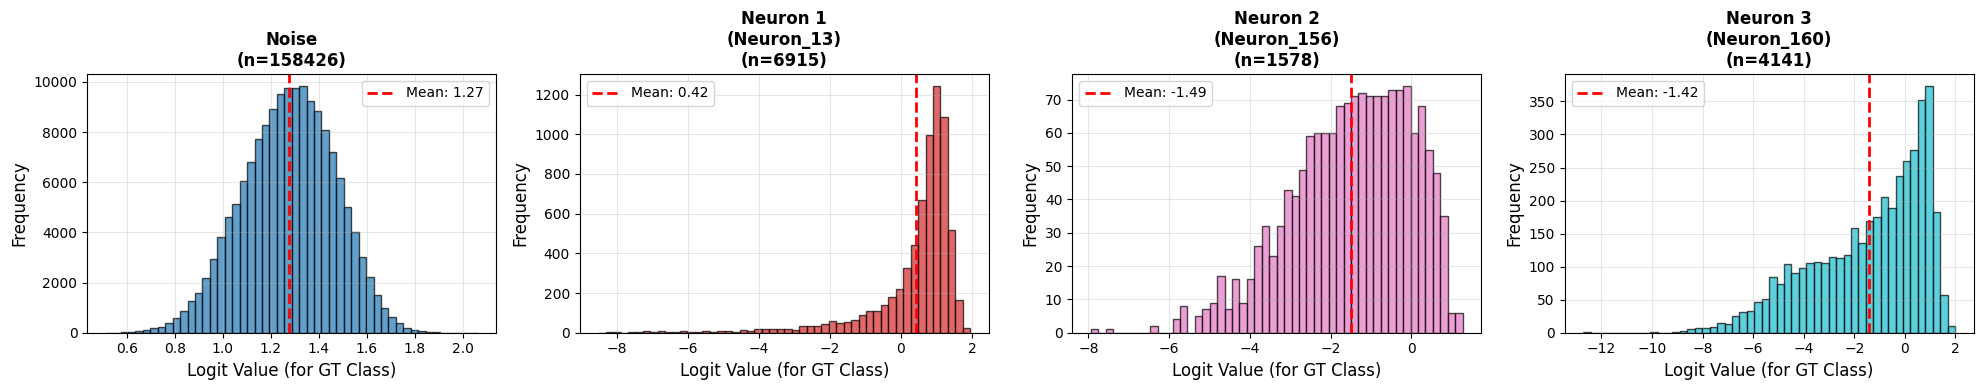


Logits Statistics by GT Class (Logit value for the correct class)

Noise:
  Count: 158426
  Mean logit: 1.2744
  Std logit: 0.1917
  Min logit: 0.5117
  Max logit: 2.0626
  Median logit: 1.2810

Neuron 1 (Neuron_13):
  Count: 6915
  Mean logit: 0.4176
  Std logit: 1.2755
  Min logit: -8.5252
  Max logit: 1.9485
  Median logit: 0.8179

Neuron 2 (Neuron_156):
  Count: 1578
  Mean logit: -1.4852
  Std logit: 1.4822
  Min logit: -7.9400
  Max logit: 1.2691
  Median logit: -1.3196

Neuron 3 (Neuron_160):
  Count: 4141
  Mean logit: -1.4207
  Std logit: 2.2259
  Min logit: -12.7198
  Max logit: 1.9881
  Median logit: -0.8443


In [11]:
# Visualize logits distribution for all detected spikes
# Group by matched neurons and noise

from utils_clique import SpikeCNN, SpikeSet
from torch.utils import data
from tqdm import tqdm

# Select clique to analyze
clique_id_analyze = 0
run_id_analyze = 1

# Load evaluation data and model
model_save_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "model_save" / f"run_{run_id_analyze}"
eval_data_dir = model_save_dir / "eval_data"

if not eval_data_dir.exists():
    print(f"Evaluation data not found at {eval_data_dir}")
else:
    # Load data
    test_loader = data.DataLoader(
        SpikeSet(str(eval_data_dir / 'x_test.npy'),
                str(eval_data_dir / 'y_test.npy')),
        batch_size=256, shuffle=False
    )
    
    # Get input shape and number of classes
    sample_x, _ = test_loader.dataset[0]
    input_shape = sample_x.shape[1:]
    n_channels, n_time = input_shape
    
    # Get number of classes from training data
    train_data_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "train_data"
    neuron_mapping_path = train_data_dir / "neuron_mapping.pkl"
    
    if neuron_mapping_path.exists():
        with open(neuron_mapping_path, 'rb') as f:
            train_neuron_mapping = pickle.load(f)
        NUM_CLASSES = len(train_neuron_mapping['unique_neurons']) + 1
        id_to_neuron = train_neuron_mapping['id_to_neuron']
    else:
        raise FileNotFoundError(f"neuron_mapping.pkl not found at {neuron_mapping_path}")
    
    # Load model
    model = SpikeCNN(NUM_CLASSES).to(device)
    best_model_path = model_save_dir / 'best_spike_cls.pth'
    final_model_path = model_save_dir / 'final_spike_cls.pth'
    
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"Loaded best model from: {best_model_path}")
    elif final_model_path.exists():
        model.load_state_dict(torch.load(final_model_path, map_location=device))
        print(f"Loaded final model from: {final_model_path}")
    else:
        raise FileNotFoundError(f"Model file not found")
    
    model.eval()
    
    # Get all logits and ground truth labels
    all_logits = []
    all_ground_truth = []
    
    print(f"\nCollecting logits for {len(test_loader.dataset)} samples...")
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Collecting logits"):
            x, y = x.to(device), y.to(device)
            logits = model(x)  # (batch_size, num_classes)
            all_logits.append(logits.cpu().numpy())
            all_ground_truth.append(y.cpu().numpy())
    
    # Combine results
    all_logits = np.concatenate(all_logits, axis=0)  # (n_samples, num_classes)
    all_ground_truth = np.concatenate(all_ground_truth, axis=0)  # (n_samples,)
    
    # Group by GT labels
    unique_labels = np.unique(all_ground_truth)
    print(f"\nUnique GT labels: {unique_labels}")
    
    # For each GT class, get the logit value for that class
    # This shows the model's confidence for the correct class
    class_logits_dict = {}
    for label in sorted(unique_labels):
        mask = all_ground_truth == label
        # Get logit value for this class (the correct class)
        class_logits = all_logits[mask, label]  # Logit for the GT class
        class_logits_dict[label] = class_logits
    
    # Create figure with subplots for each class
    n_classes_to_plot = len(unique_labels)
    fig, axes = plt.subplots(1, n_classes_to_plot, figsize=(5*n_classes_to_plot, 4))
    if n_classes_to_plot == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes_to_plot))
    
    for idx, label in enumerate(sorted(unique_labels)):
        class_logits = class_logits_dict[label]
        
        # Get class name
        if label == 0:
            class_name = "Noise"
        else:
            neuron_name = id_to_neuron.get(label, f"neuron_{label}")
            class_name = f"Neuron {label}\n({neuron_name})"
        
        # Plot histogram
        axes[idx].hist(class_logits, bins=50, alpha=0.7, color=colors[idx], edgecolor='black')
        axes[idx].set_xlabel('Logit Value (for GT Class)', fontsize=12)
        axes[idx].set_ylabel('Frequency', fontsize=12)
        axes[idx].set_title(f'{class_name}\n(n={len(class_logits)})', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics
        mean_logit = class_logits.mean()
        std_logit = class_logits.std()
        axes[idx].axvline(mean_logit, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_logit:.2f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"Logits Statistics by GT Class (Logit value for the correct class)")
    print(f"{'='*80}")
    for label in sorted(unique_labels):
        class_logits = class_logits_dict[label]
        
        if label == 0:
            class_name = "Noise"
        else:
            neuron_name = id_to_neuron.get(label, f"neuron_{label}")
            class_name = f"Neuron {label} ({neuron_name})"
        
        print(f"\n{class_name}:")
        print(f"  Count: {len(class_logits)}")
        print(f"  Mean logit: {class_logits.mean():.4f}")
        print(f"  Std logit: {class_logits.std():.4f}")
        print(f"  Min logit: {class_logits.min():.4f}")
        print(f"  Max logit: {class_logits.max():.4f}")
        print(f"  Median logit: {np.median(class_logits):.4f}")


Loaded best model from: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/best_spike_cls.pth




Unique GT labels in training data: [0 1 2 3 4]


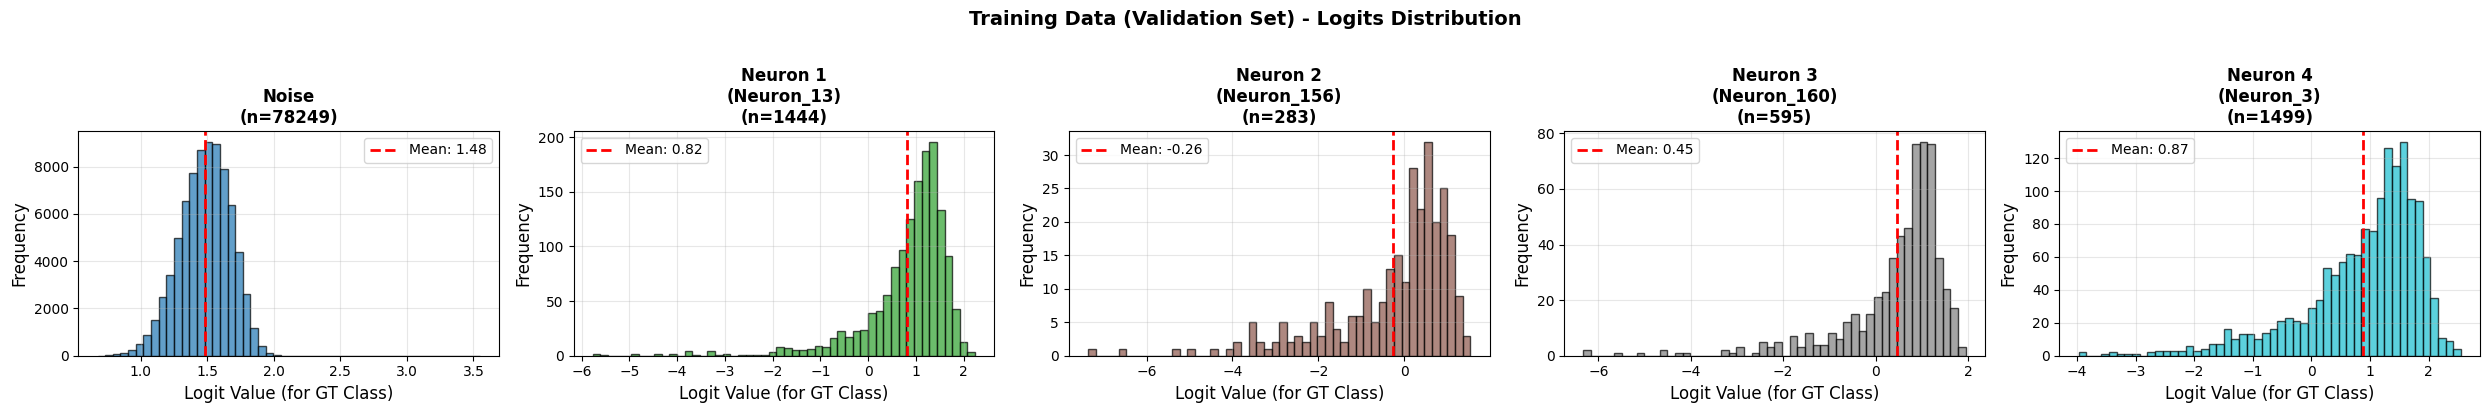


Training Data Logits Statistics by GT Class (Logit value for the correct class)

Noise:
  Count: 78249
  Mean logit: 1.4821
  Std logit: 0.1919
  Min logit: 0.6758
  Max logit: 3.5484
  Median logit: 1.4926

Neuron 1 (Neuron_13):
  Count: 1444
  Mean logit: 0.8179
  Std logit: 0.9496
  Min logit: -5.7680
  Max logit: 2.2426
  Median logit: 1.0656

Neuron 2 (Neuron_156):
  Count: 283
  Mean logit: -0.2649
  Std logit: 1.4367
  Min logit: -7.3629
  Max logit: 1.5416
  Median logit: 0.2316

Neuron 3 (Neuron_160):
  Count: 595
  Mean logit: 0.4547
  Std logit: 1.1330
  Min logit: -6.3265
  Max logit: 1.9472
  Median logit: 0.8092

Neuron 4 (Neuron_3):
  Count: 1499
  Mean logit: 0.8738
  Std logit: 1.0013
  Min logit: -3.9728
  Max logit: 2.5525
  Median logit: 1.1623


In [12]:
# Visualize logits distribution for training data
# Group by neurons and noise

from utils_clique import SpikeCNN, SpikeSet
from torch.utils import data
from tqdm import tqdm

# Select clique to analyze
clique_id_analyze = 0
run_id_analyze = 1

# Load training data and model
model_save_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "model_save" / f"run_{run_id_analyze}"
train_data_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "train_data"

if not train_data_dir.exists():
    print(f"Training data not found at {train_data_dir}")
else:
    # Load training data (use validation set for visualization)
    train_loader = data.DataLoader(
        SpikeSet(str(train_data_dir / 'x_val.npy'),
                str(train_data_dir / 'y_val.npy')),
        batch_size=256, shuffle=False
    )
    
    # Get input shape and number of classes
    sample_x, _ = train_loader.dataset[0]
    input_shape = sample_x.shape[1:]
    n_channels, n_time = input_shape
    
    # Get number of classes from training data
    neuron_mapping_path = train_data_dir / "neuron_mapping.pkl"
    
    if neuron_mapping_path.exists():
        with open(neuron_mapping_path, 'rb') as f:
            train_neuron_mapping = pickle.load(f)
        NUM_CLASSES = len(train_neuron_mapping['unique_neurons']) + 1
        id_to_neuron = train_neuron_mapping['id_to_neuron']
    else:
        raise FileNotFoundError(f"neuron_mapping.pkl not found at {neuron_mapping_path}")
    
    # Load model
    model = SpikeCNN(NUM_CLASSES).to(device)
    best_model_path = model_save_dir / 'best_spike_cls.pth'
    final_model_path = model_save_dir / 'final_spike_cls.pth'
    
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"Loaded best model from: {best_model_path}")
    elif final_model_path.exists():
        model.load_state_dict(torch.load(final_model_path, map_location=device))
        print(f"Loaded final model from: {final_model_path}")
    else:
        raise FileNotFoundError(f"Model file not found")
    
    model.eval()
    
    # Get all logits and ground truth labels
    all_logits = []
    all_ground_truth = []
    
    print(f"\nCollecting logits for training data (validation set): {len(train_loader.dataset)} samples...")
    with torch.no_grad():
        for x, y in tqdm(train_loader, desc="Collecting logits"):
            x, y = x.to(device), y.to(device)
            logits = model(x)  # (batch_size, num_classes)
            all_logits.append(logits.cpu().numpy())
            all_ground_truth.append(y.cpu().numpy())
    
    # Combine results
    all_logits = np.concatenate(all_logits, axis=0)  # (n_samples, num_classes)
    all_ground_truth = np.concatenate(all_ground_truth, axis=0)  # (n_samples,)
    
    # Group by GT labels
    unique_labels = np.unique(all_ground_truth)
    print(f"\nUnique GT labels in training data: {unique_labels}")
    
    # For each GT class, get the logit value for that class
    # This shows the model's confidence for the correct class
    class_logits_dict = {}
    for label in sorted(unique_labels):
        mask = all_ground_truth == label
        # Get logit value for this class (the correct class)
        class_logits = all_logits[mask, label]  # Logit for the GT class
        class_logits_dict[label] = class_logits
    
    # Create figure with subplots for each class
    n_classes_to_plot = len(unique_labels)
    fig, axes = plt.subplots(1, n_classes_to_plot, figsize=(5*n_classes_to_plot, 4))
    if n_classes_to_plot == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes_to_plot))
    
    for idx, label in enumerate(sorted(unique_labels)):
        class_logits = class_logits_dict[label]
        
        # Get class name
        if label == 0:
            class_name = "Noise"
        else:
            neuron_name = id_to_neuron.get(label, f"neuron_{label}")
            class_name = f"Neuron {label}\n({neuron_name})"
        
        # Plot histogram
        axes[idx].hist(class_logits, bins=50, alpha=0.7, color=colors[idx], edgecolor='black')
        axes[idx].set_xlabel('Logit Value (for GT Class)', fontsize=12)
        axes[idx].set_ylabel('Frequency', fontsize=12)
        axes[idx].set_title(f'{class_name}\n(n={len(class_logits)})', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics
        mean_logit = class_logits.mean()
        std_logit = class_logits.std()
        axes[idx].axvline(mean_logit, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_logit:.2f}')
        axes[idx].legend()
    
    plt.suptitle('Training Data (Validation Set) - Logits Distribution', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"Training Data Logits Statistics by GT Class (Logit value for the correct class)")
    print(f"{'='*80}")
    for label in sorted(unique_labels):
        class_logits = class_logits_dict[label]
        
        if label == 0:
            class_name = "Noise"
        else:
            neuron_name = id_to_neuron.get(label, f"neuron_{label}")
            class_name = f"Neuron {label} ({neuron_name})"
        
        print(f"\n{class_name}:")
        print(f"  Count: {len(class_logits)}")
        print(f"  Mean logit: {class_logits.mean():.4f}")
        print(f"  Std logit: {class_logits.std():.4f}")
        print(f"  Min logit: {class_logits.min():.4f}")
        print(f"  Max logit: {class_logits.max():.4f}")
        print(f"  Median logit: {np.median(class_logits):.4f}")


Loaded best model from: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/20251222/output/clique_00/model_save/run_1/best_spike_cls.pth

Extracting features for 171060 samples...


Extracting features: 100%|██████████| 669/669 [00:06<00:00, 110.72it/s]



Randomly sampling 50000 from 171060 samples...

Performing UMAP dimensionality reduction (50000 samples, 64D -> 2D)...


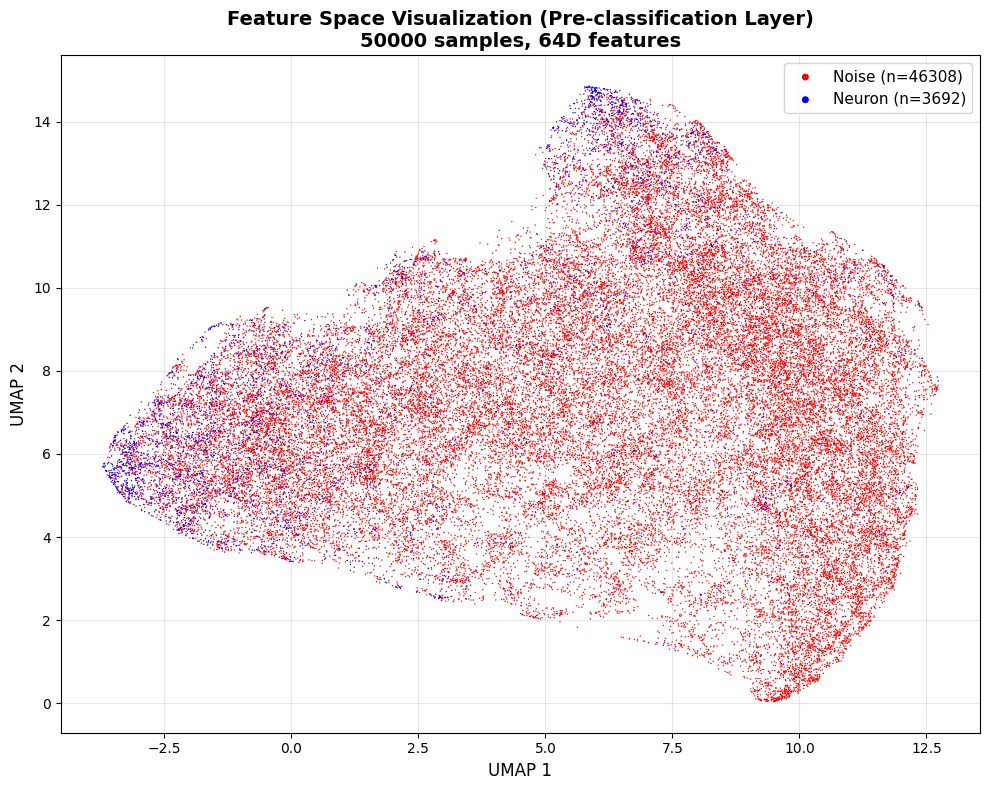


Feature Extraction Statistics
Total samples: 171060
Samples used for visualization: 50000
Feature dimension: 32

Label distribution:
  Noise (label=0): 46308 (92.62%)
  Neuron (label>0): 3692 (7.38%)

Neuron class distribution:
  Class 1: 2046 samples
  Class 2: 436 samples
  Class 3: 1210 samples


In [ ]:
# Extract features before classification layer and visualize with UMAP
# Label: noise (0) vs neuron (1+)

from utils_clique import SpikeCNN, SpikeSet
from torch.utils import data
from tqdm import tqdm
import umap

# Select clique to analyze
clique_id_analyze = 0
run_id_analyze = 1

# Load evaluation data and model
model_save_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "model_save" / f"run_{run_id_analyze}"
eval_data_dir = model_save_dir / "eval_data"

if not eval_data_dir.exists():
    print(f"Evaluation data not found at {eval_data_dir}")
else:
    # Load data
    test_loader = data.DataLoader(
        SpikeSet(str(eval_data_dir / 'x_test.npy'),
                str(eval_data_dir / 'y_test.npy')),
        batch_size=256, shuffle=False
    )
    
    # Get input shape and number of classes
    sample_x, _ = test_loader.dataset[0]
    input_shape = sample_x.shape[1:]
    n_channels, n_time = input_shape
    
    # Get number of classes from training data
    train_data_dir = Path(base_save_dir) / f"clique_{clique_id_analyze:02d}" / "train_data"
    neuron_mapping_path = train_data_dir / "neuron_mapping.pkl"
    
    if neuron_mapping_path.exists():
        with open(neuron_mapping_path, 'rb') as f:
            train_neuron_mapping = pickle.load(f)
        NUM_CLASSES = len(train_neuron_mapping['unique_neurons']) + 1
    else:
        raise FileNotFoundError(f"neuron_mapping.pkl not found at {neuron_mapping_path}")
    
    # Load model
    model = SpikeCNN(NUM_CLASSES).to(device)
    best_model_path = model_save_dir / 'best_spike_cls.pth'
    final_model_path = model_save_dir / 'final_spike_cls.pth'
    
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"Loaded best model from: {best_model_path}")
    elif final_model_path.exists():
        model.load_state_dict(torch.load(final_model_path, map_location=device))
        print(f"Loaded final model from: {final_model_path}")
    else:
        raise FileNotFoundError(f"Model file not found")
    
    model.eval()
    
    # Extract features (before classification layer)
    # Feature is after Linear(64, 32) + ReLU: (B, 32)
    all_features = []
    all_ground_truth = []
    
    print(f"\nExtracting features for {len(test_loader.dataset)} samples...")
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Extracting features"):
            x, y = x.to(device), y.to(device)
            # Extract features before the final Linear layer
            # Forward through cnn -> gap -> flatten -> Linear(64,32) -> ReLU
            feat_64 = model.gap(model.cnn(x)).flatten(1)  # (B, 64)
            # fc[0]=Flatten, fc[1]=Linear(64,32), fc[2]=ReLU
            # Skip Flatten since feat_64 is already flattened
            feat_32 = model.fc[2](model.fc[1](feat_64))  # Linear(64,32) -> ReLU -> (B, 32)
            all_features.append(feat_32.cpu().numpy())
            all_ground_truth.append(y.cpu().numpy())
    
    # Combine results
    all_features = np.concatenate(all_features, axis=0)  # (n_samples, 64)
    all_ground_truth = np.concatenate(all_ground_truth, axis=0)  # (n_samples,)
    
    # Create binary labels: noise (0) vs neuron (1)
    binary_labels = (all_ground_truth > 0).astype(int)  # 0=noise, 1=neuron
    
    # Random sampling: 50000 samples
    n_samples_total = len(all_features)
    n_samples_to_plot = min(50000, n_samples_total)
    
    if n_samples_total > n_samples_to_plot:
        print(f"\nRandomly sampling {n_samples_to_plot} from {n_samples_total} samples...")
        np.random.seed(42)
        sample_indices = np.random.choice(n_samples_total, n_samples_to_plot, replace=False)
        features_sample = all_features[sample_indices]
        binary_labels_sample = binary_labels[sample_indices]
        gt_labels_sample = all_ground_truth[sample_indices]
    else:
        print(f"\nUsing all {n_samples_total} samples...")
        features_sample = all_features
        binary_labels_sample = binary_labels
        gt_labels_sample = all_ground_truth
    
    # UMAP dimensionality reduction
    print(f"\nPerforming UMAP dimensionality reduction ({n_samples_to_plot} samples, 64D -> 2D)...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_coords = reducer.fit_transform(features_sample)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Separate noise and neuron
    noise_mask = binary_labels_sample == 0
    neuron_mask = binary_labels_sample == 1
    
    # Plot noise
    if noise_mask.sum() > 0:
        ax.scatter(umap_coords[noise_mask, 0], umap_coords[noise_mask, 1], 
                  c='red', s=1, alpha=1, label=f'Noise (n={noise_mask.sum()})', edgecolors='none')
    
    # Plot neurons
    if neuron_mask.sum() > 0:
        ax.scatter(umap_coords[neuron_mask, 0], umap_coords[neuron_mask, 1], 
                  c='blue', s=1, alpha=1, label=f'Neuron (n={neuron_mask.sum()})', edgecolors='none')
    
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title(f'Feature Space Visualization (Pre-classification Layer)\n{n_samples_to_plot} samples, 64D features', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, markerscale=5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"Feature Extraction Statistics")
    print(f"{'='*80}")
    print(f"Total samples: {n_samples_total}")
    print(f"Samples used for visualization: {n_samples_to_plot}")
    print(f"Feature dimension: {all_features.shape[1]}")
    print(f"\nLabel distribution:")
    print(f"  Noise (label=0): {np.sum(binary_labels_sample == 0)} ({100*np.sum(binary_labels_sample == 0)/len(binary_labels_sample):.2f}%)")
    print(f"  Neuron (label>0): {np.sum(binary_labels_sample == 1)} ({100*np.sum(binary_labels_sample == 1)/len(binary_labels_sample):.2f}%)")
    
    if neuron_mask.sum() > 0:
        print(f"\nNeuron class distribution:")
        unique_neuron_labels = np.unique(gt_labels_sample[neuron_mask])
        for label in sorted(unique_neuron_labels):
            count = np.sum(gt_labels_sample == label)
            print(f"  Class {label}: {count} samples")


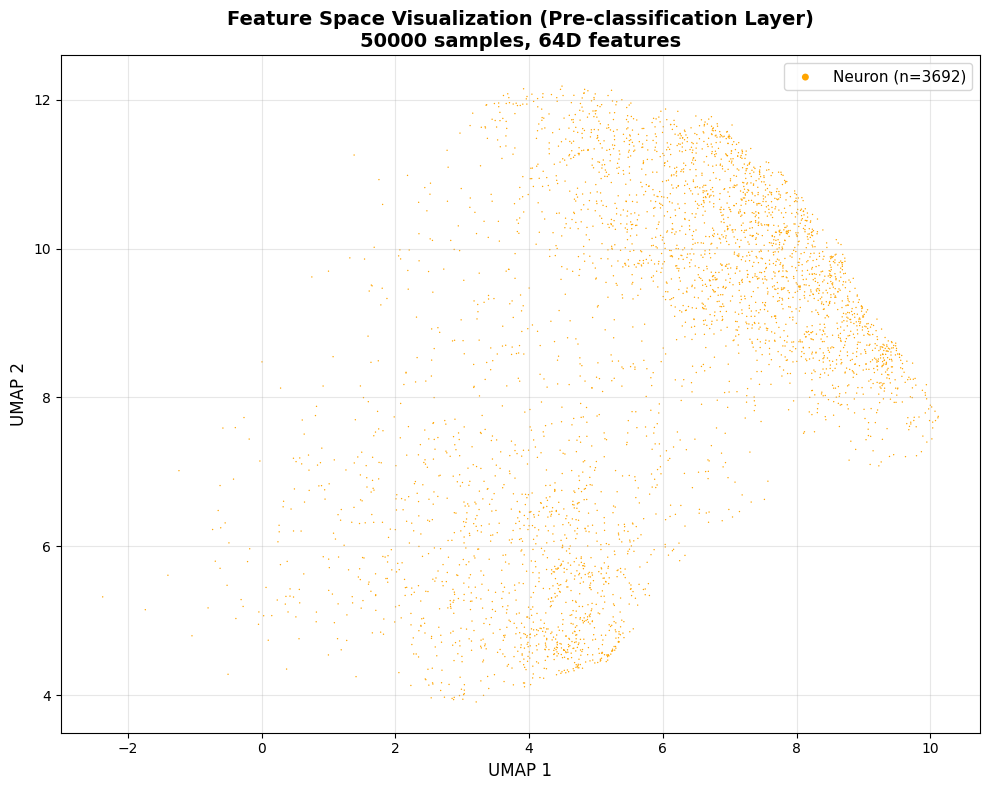

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

if neuron_mask.sum() > 0:
    ax.scatter(umap_coords[neuron_mask, 0], umap_coords[neuron_mask, 1], 
                c='orange', s=1, alpha=1, label=f'Neuron (n={neuron_mask.sum()})', edgecolors='none')

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title(f'Feature Space Visualization (Pre-classification Layer)\n{n_samples_to_plot} samples, 64D features', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Summary of evaluation results
print(f"\n{'='*80}")
print(f"Evaluation Summary")
print(f"{'='*80}")

for clique_id, clique_results in all_eval_results.items():
    print(f"\nClique {clique_id:02d}:")
    for run_id, results in clique_results.items():
        print(f"  Run {run_id}:")
        print(f"    Accuracy: {results.get('accuracy', 0):.4f}")
        print(f"    Precision: {results.get('precision', 0):.4f}")
        print(f"    Recall: {results.get('recall', 0):.4f}")
        print(f"    F1 Score: {results.get('f1_score', 0):.4f}")



Evaluation Summary

Clique 00:
  Run 1:
    Accuracy: 0.9215
    Precision: 0.0000
    Recall: 0.0000
    F1 Score: 0.0000


In [10]:
# Evaluation completed
print("\n" + "="*80)
print("Evaluation completed!")
print("="*80)



Evaluation completed!
